In [1]:
import warnings
from glob import glob

import pandas as pd
import seaborn as sns
from category_encoders import OneHotEncoder
from IPython.display import VimeoVideo
from ipywidgets import Dropdown, FloatSlider, IntSlider, interact
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge  # noqa F401
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.utils.validation import check_is_fitted

warnings.simplefilter(action="ignore", category=FutureWarning)

In [2]:
def wrangle(filepath):
    # Read CSV file
    df = pd.read_csv(filepath)

    # Subset data: Apartments in "Capital Federal", less than 400,000
    mask_ba = df["place_with_parent_names"].str.contains("Capital Federal")
    mask_apt = df["property_type"] == "apartment"
    mask_price = df["price_aprox_usd"] < 400_000
    df = df[mask_ba & mask_apt & mask_price]

    # Subset data: Remove outliers for "surface_covered_in_m2"
    low, high = df["surface_covered_in_m2"].quantile([0.1, 0.9])
    mask_area = df["surface_covered_in_m2"].between(low, high)
    df = df[mask_area]

    # Split "lat-lon" column
    df[["lat", "lon"]] = df["lat-lon"].str.split(",", expand=True).astype(float)
    df.drop(columns="lat-lon", inplace=True)

    # Get place name
    df["neighborhood"] = df["place_with_parent_names"].str.split("|", expand=True)[3]
    df.drop(columns="place_with_parent_names", inplace=True)

    # drop columns above half null values
    df.drop(columns=["floor", "expenses"], inplace=True)
    df.drop(columns=["operation",
                     "property_type",
                     "currency",
                     "properati_url"], inplace =True)
    df.drop(columns= ["price",
                      "price_aprox_local_currency",     
                      "price_usd_per_m2",
                      "price_per_m2"], inplace=True)
    df.drop(columns=["rooms", "surface_total_in_m2"], inplace=True)
    
    return df

In [6]:
files = glob("../data/raw/buenos-aires-real-estate-*.csv")
files

['../data/raw\\buenos-aires-real-estate-1.csv',
 '../data/raw\\buenos-aires-real-estate-2.csv',
 '../data/raw\\buenos-aires-real-estate-3.csv',
 '../data/raw\\buenos-aires-real-estate-4.csv',
 '../data/raw\\buenos-aires-real-estate-5.csv']

In [7]:
frames = [wrangle(file) for file in files]

In [8]:
df = pd.concat(frames, ignore_index=True)
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6582 entries, 0 to 6581
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        6582 non-null   float64
 1   surface_covered_in_m2  6582 non-null   float64
 2   lat                    6316 non-null   float64
 3   lon                    6316 non-null   float64
 4   neighborhood           6582 non-null   object 
dtypes: float64(4), object(1)
memory usage: 257.2+ KB
None


,price_aprox_usd,surface_covered_in_m2,lat,lon,neighborhood
0,129000.0,70.0,-34.584651,-58.454693,Chacarita
1,87000.0,42.0,-34.638979,-58.500115,Villa Luro
2,118000.0,54.0,-34.615847,-58.459957,Caballito
3,57000.0,42.0,-34.625222,-58.382382,Constitución
4,90000.0,50.0,-34.610610,-58.412511,Once


Explore
The first thing we need to consider when trying to use all the features df is missing values. While it's true you can impute missing values, 
there still needs to be enough data in a column to do a good imputation. A general rule is that, if more than half of the data in a column is missing,
it's better to drop it then try imputing.


Take a look at the output from df.info() above. Are there columns where more than half of the values are NaN? If so, those columns need to go!

In [ ]:
Task 2.4.4: Modify your wrangle function to drop any columns that are more than half NaN values. Be sure to rerun all the cells above before you 
continue.

Inspect a DataFrame using the shape, info, and head in pandas.
Drop a column from a DataFrame using pandas.

In [9]:
df.isnull().sum() / len(df)

price_aprox_usd          0.000000
surface_covered_in_m2    0.000000
lat                      0.040413
lon                      0.040413
neighborhood             0.000000
dtype: float64

The next thing we need to look out for are categorical columns with low or high cardinality. If there's only one category in a column, it won't provide
any unique information to our model. At the other extreme, columns where nearly every row has its own category won't help our model in identifying
useful trends in the data.

Let's take a look at the cardinality of our features.



In [ ]:
Task 2.4.5: Calculate the number of unique values for each non-numeric feature in df.

Here, we can see that columns like "operation" have only one value in them, while every row in "properati_url" has a unique value. These are clear 
examples of high- and low-cardinality features that we shouldn't include in our model.


Task 2.4.6: Modify your wrangle function to drop high- and low-cardinality categorical features.
Be sure to rerun all the cells above before you continue.

It's also important for us to drop any columns that would constitute leakage, that is, features that were created using our target or that would give 
our model information that it won't have access to when it's deployed.



Task 2.4.7: Modify your wrangle function to drop any features that would constitute leakage.

Be sure to rerun all the cells above before you continue.

In [8]:
df.select_dtypes("number").nunique()

price_aprox_usd          1364
surface_covered_in_m2      72
lat                      4406
lon                      4407
dtype: int64

Finally, the last issue we need to keep an eye out for is multicollinearity, that is, features in our feature matrix that are highly correlated with 
each other. A good way to detect this is to use a heatmap. Let's make one!

In [ ]:
Task 2.4.8: Plot a correlation heatmap of the remaining numerical features in df. Since "price_aprox_usd" will be your target, you don't need to 
include it in your heatmap.

<Axes: >

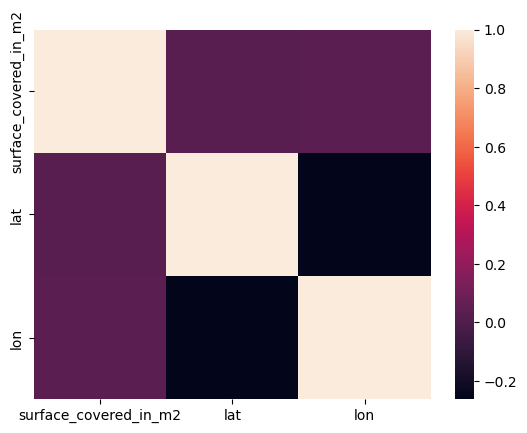

In [10]:
corr = df.select_dtypes("number").drop(columns="price_aprox_usd").corr()
sns.heatmap(corr)

In [11]:
df

,price_aprox_usd,surface_covered_in_m2,lat,lon,neighborhood
0,129000.0,70.0,-34.584651,-58.454693,Chacarita
1,87000.0,42.0,-34.638979,-58.500115,Villa Luro
2,118000.0,54.0,-34.615847,-58.459957,Caballito
3,57000.0,42.0,-34.625222,-58.382382,Constitución
4,90000.0,50.0,-34.610610,-58.412511,Once
...,...,...,...,...,...
6577,290000.0,83.0,-34.639528,-58.519666,Liniers
6578,150000.0,45.0,-34.597825,-58.416439,Palermo
6579,65000.0,42.0,-34.652233,-58.490739,Mataderos
6580,91440.0,48.0,-34.648761,-58.500180,Mataderos


In [12]:
target = "price_aprox_usd"
y_train= df[target]
features=["surface_covered_in_m2", "lat","lon",	"neighborhood"]
X_train= df[features]

In [13]:
y_mean= y_train.mean()
y_pred_baseline= [y_mean] * len(y_train)

print("Mean apt price:", y_mean)

print("Baseline MAE:", mean_absolute_error(y_train, y_pred_baseline))

Mean apt price: 132383.83701458524
Baseline MAE: 44860.10834274133


In [14]:
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    SimpleImputer(),
    Ridge()
)
model.fit(X_train, y_train)

,steps,"[('onehotencoder', ...), ('simpleimputer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,verbose,0
,cols,['neighborhood']
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,use_cat_names,True


In [15]:
y_pred_training= model.predict(X_train)
mae_training = mean_absolute_error(y_train, y_pred_training)
print("Training MAE:", mae_training)

Training MAE: 24207.107190330145


In [ ]:
Task 2.4.14: Run the code below to import your test data buenos-aires-test-features.csv into a DataFrame and generate a list of predictions using your 
model. After the code runs successfully, click on the Check Activity button on the left pane to verify your predictions.

In [17]:
X_test = pd.read_csv("../data/raw/buenos-aires-test-features.csv")[features]
y_pred_test = pd.Series(model.predict(X_test))
y_pred_test.head()

0    231122.403569
1    162572.942392
2     68477.949626
3     63521.438989
4    105694.463885
dtype: float64

In [18]:
def make_prediction(area, lat, lon, neighborhood):
    data={
        "surface_covered_in_m2": area,
        "lat": lat,
        "lon": lon,
        "neighborhood": neighborhood
    }
    df= pd.DataFrame(data, index=[0])
    prediction = model.predict(df).round(2)[0]
    return f"Predicted apartment price: ${prediction}"

In [19]:
make_prediction(110, -34.60, -58.46, "Villa Crespo")

'Predicted apartment price: $250775.11'

In [20]:
interact(
    make_prediction,
    area=IntSlider(
        min=X_train["surface_covered_in_m2"].min(),
        max=X_train["surface_covered_in_m2"].max(),
        value=X_train["surface_covered_in_m2"].mean(),
    ),
    lat=FloatSlider(
        min=X_train["lat"].min(),
        max=X_train["lat"].max(),
        step=0.01,
        value=X_train["lat"].mean(),
    ),
    lon=FloatSlider(
        min=X_train["lon"].min(),
        max=X_train["lon"].max(),
        step=0.01,
        value=X_train["lon"].mean(),
    ),
    neighborhood=Dropdown(options=sorted(X_train["neighborhood"].unique())),
);

interactive(children=(IntSlider(value=53, description='area', max=101, min=30), FloatSlider(value=-34.59890626…